# Phase 5 — Explainability (Grad-CAM)

In [1]:
import sys
sys.path.append('../src')

import csv
import random
import torch
import matplotlib.pyplot as plt

from config import MODELS_DIR, METADATA_DIR, GRADCAM_DIR, ensure_dirs
from models.improved_cnn import ImprovedCNN
from gradcam import GradCAM, explain_sample

ensure_dirs()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


Using device: cpu


## 1. Load model + hook the last conv layer

In [2]:
model = ImprovedCNN(num_classes=38).to(device)
ckpt_path = MODELS_DIR / 'improved' / 'improved_best.pt'
model.load_state_dict(torch.load(ckpt_path, map_location=device))

# Last ConvBlock's Conv2d — deepest layer with spatial detail still intact,
# standard choice for Grad-CAM (before GAP collapses spatial dims).
target_layer = model.features[-1].block[0]
gradcam = GradCAM(model, target_layer)

print(f"Loaded: {ckpt_path}")
print(f"Target layer: {target_layer}")


Loaded: G:\Project CNN\models\improved\improved_best.pt
Target layer: Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))


## 2. Load Phase 4 predictions

In [3]:
preds_csv = METADATA_DIR / 'test_predictions.csv'
with open(preds_csv) as f:
    rows = list(csv.DictReader(f))

correct_rows = [r for r in rows if r['correct'] == '1']
incorrect_rows = [r for r in rows if r['correct'] == '0']

print(f"Total: {len(rows)} | Correct: {len(correct_rows)} | Incorrect: {len(incorrect_rows)}")


Total: 8179 | Correct: 7985 | Incorrect: 194


## 3. Grad-CAM on correct predictions

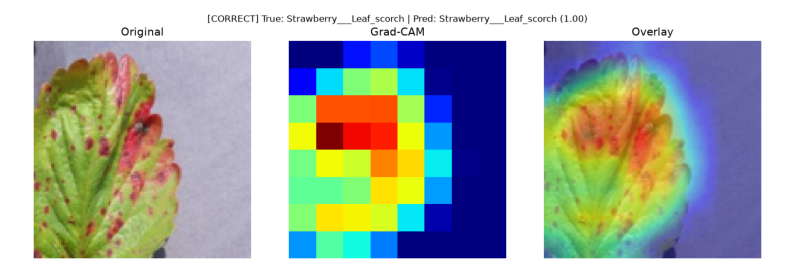

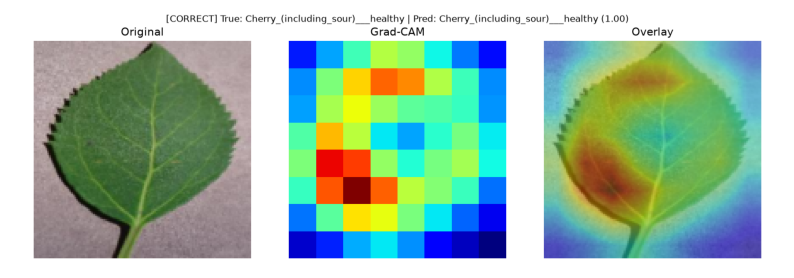

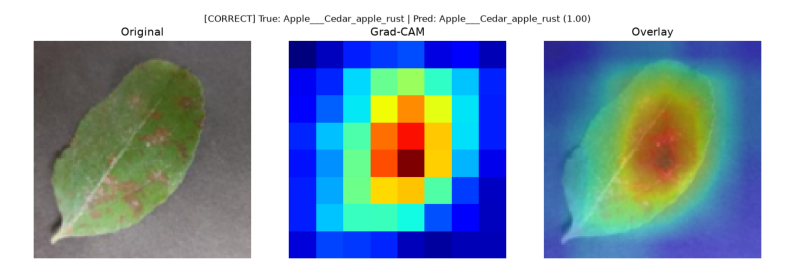

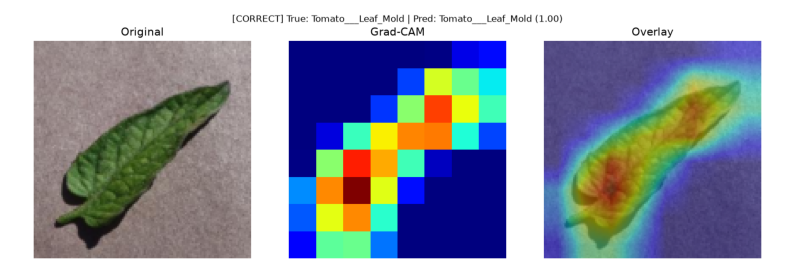

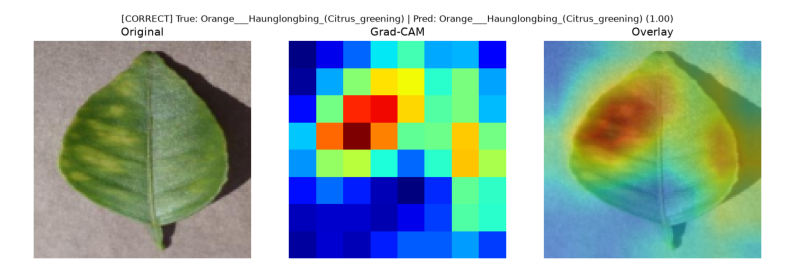

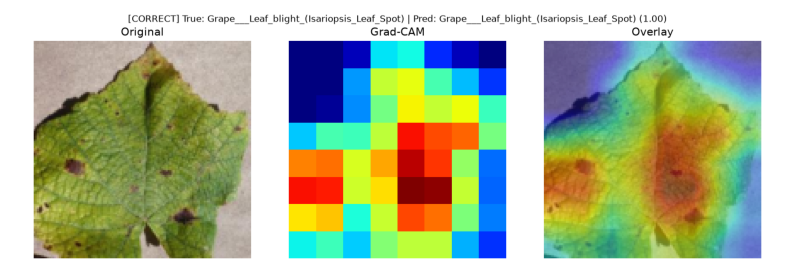

In [4]:
random.seed(42)
sample_correct = random.sample(correct_rows, min(6, len(correct_rows)))

for i, row in enumerate(sample_correct):
    save_path = GRADCAM_DIR / f'correct_{i:02d}.png'
    explain_sample(gradcam, row['filepath'], row['true_class'], row['pred_class'], device, save_path)

    from PIL import Image
    img = Image.open(save_path)
    plt.figure(figsize=(10, 3.5))
    plt.imshow(img)
    plt.axis('off')
    plt.show()


## 4. Grad-CAM on incorrect predictions

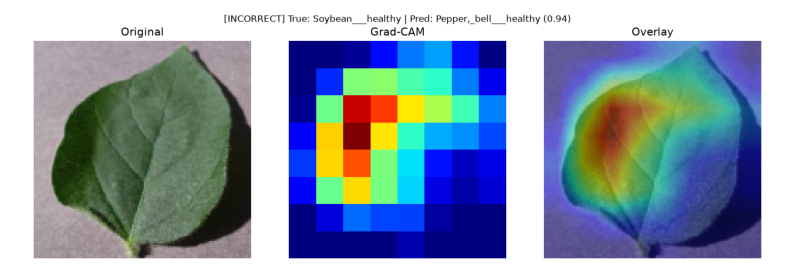

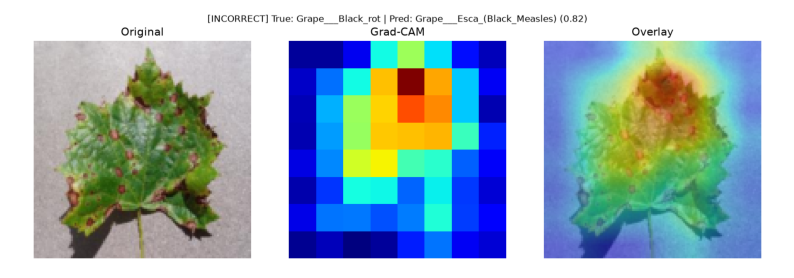

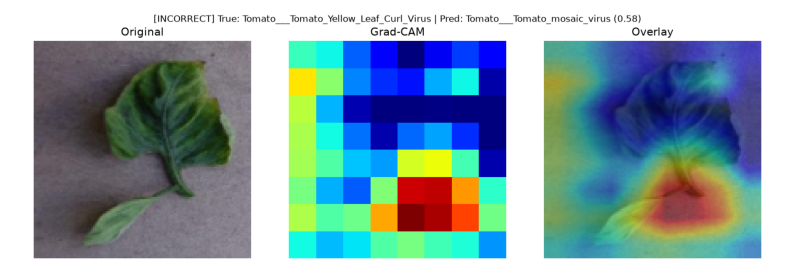

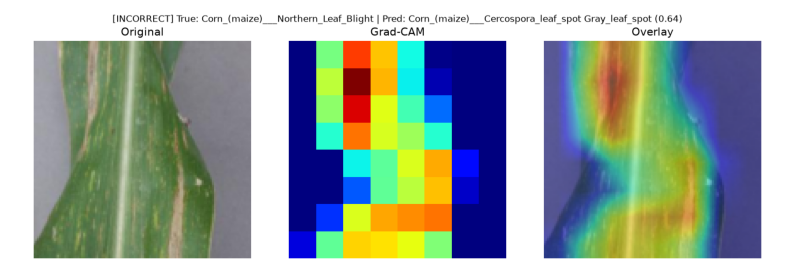

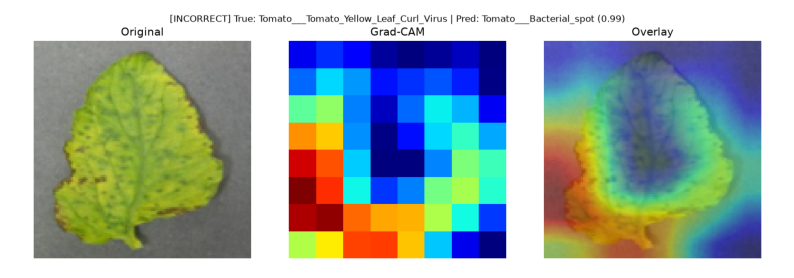

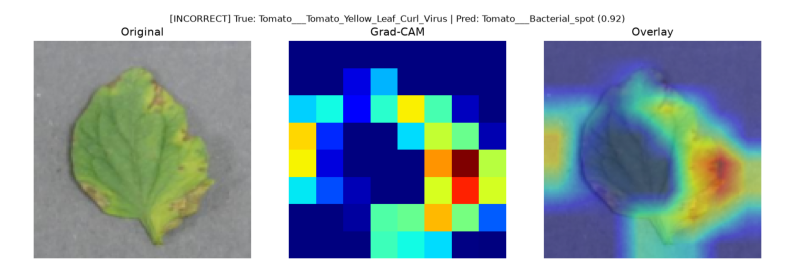

In [5]:
if incorrect_rows:
    sample_incorrect = random.sample(incorrect_rows, min(6, len(incorrect_rows)))

    for i, row in enumerate(sample_incorrect):
        save_path = GRADCAM_DIR / f'incorrect_{i:02d}.png'
        explain_sample(gradcam, row['filepath'], row['true_class'], row['pred_class'], device, save_path)

        from PIL import Image
        img = Image.open(save_path)
        plt.figure(figsize=(10, 3.5))
        plt.imshow(img)
        plt.axis('off')
        plt.show()
else:
    print("No incorrect predictions in the test set sample to inspect.")
